# Educacion - Avenida Ciudad de Cali

**Zona:** Corredor Avenida Ciudad de Cali  
**Unidad de analisis:** tramos `T1` a `T8`  
**Alcance:** sedes educativas por tramo, SIMPADE, SIMAT Anexo 6A y comparativo 2023-2025 vs corte parcial 2026.

Este notebook se deja separado del ITT principal para validar la dimension educativa antes de integrarla a Desarrollo Social.

In [7]:
import os
import re
import json
import subprocess
import importlib.util
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

BG = '#F4F6F9'
OKI_AZUL = '#0072B2'
OKI_AZUL_C = '#56B4E9'
OKI_VERDE = '#009E73'
OKI_NARANJA = '#E69F00'
OKI_BERMELL = '#D55E00'
OKI_GRIS = '#333333'
OKI_AMARILLO = '#F0E442'

TRAMOS = [f'T{i}' for i in range(1, 9)]
ANIOS_EDUC = [2023, 2024, 2025]
GRADOS_EFIC = list(range(0, 12)) + [99]

if 'google.colab' in str(type(get_ipython())):
    REPO = Path('/content/itt_repos_cali')
    if not REPO.exists() or not (REPO / '.git').exists():
        if REPO.exists():
            import shutil
            shutil.rmtree(REPO)
        print('Clonando repo en /content/itt_repos_cali')
        subprocess.run([
            'git', 'clone',
            'https://github.com/Pabandres85/itt_repos_cali.git',
            str(REPO)
        ], check=True)
    else:
        print('Actualizando repo en /content/itt_repos_cali')
        subprocess.run(['git', '-C', str(REPO), 'pull'], check=False)
else:
    REPO = Path.cwd()

DATA_DIR = REPO / 'data' / 'itt_avenida_ciudad_de_cali'
EDU_DIR = DATA_DIR / '6_Educacion'
REF_EDU_DIR = REPO / 'data' / 'referencia' / 'educacion'
OUTPUT_DIR = REPO / 'outputs' / 'educacion_avenida_ciudad_de_cali'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('REPO     :', REPO)
print('EDU_DIR  :', EDU_DIR)
print('REF_EDU  :', REF_EDU_DIR)
print('OUTPUT   :', OUTPUT_DIR)

Actualizando repo en /content/itt_repos_cali
REPO     : /content/itt_repos_cali
EDU_DIR  : /content/itt_repos_cali/data/itt_avenida_ciudad_de_cali/6_Educacion
REF_EDU  : /content/itt_repos_cali/data/referencia/educacion
OUTPUT   : /content/itt_repos_cali/outputs/educacion_avenida_ciudad_de_cali


## 1. Sedes educativas dentro de los tramos

La llave territorial principal es `DANE_SEDE`, no solo `DANE_EE`, porque una misma institucion puede tener sedes fuera del corredor.

In [8]:
def normalize_text(s):
    return (
        s.astype(str)
         .str.normalize('NFKD')
         .str.encode('ascii', errors='ignore')
         .str.decode('utf-8')
         .str.upper()
         .str.strip()
    )

def load_sedes_educacion(edu_dir):
    rows = []
    files = sorted(Path(edu_dir).glob('*.geojson'))
    for path in files:
        with open(path, 'r', encoding='utf-8') as f:
            gj = json.load(f)
        for feat in gj.get('features', []):
            p = feat.get('properties', {})
            tramo_raw = p.get('tramo', None)
            tramo = f"T{int(tramo_raw)}" if pd.notna(tramo_raw) and str(tramo_raw).strip() != '' else None
            rows.append({
                'tramo': tramo,
                'comuna': p.get('comuna'),
                'dane_ie': str(p.get('EeCodDane', '')).strip(),
                'institucion': p.get('EeNomIns'),
                'dane_sede': str(p.get('EeCoDanAnt', '')).strip(),
                'sede': p.get('EeNomSede'),
                'clase_sede': p.get('EeClaSede'),
                'estado': p.get('EeEstado'),
                'direccion': p.get('EeDirecc'),
                'barrio': p.get('EEBarVer'),
                'archivo': path.name
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['tramo', 'institucion', 'sede']).reset_index(drop=True)
    return df

df_sedes = load_sedes_educacion(EDU_DIR)

print('Sedes encontradas:', len(df_sedes))
print('Instituciones distintas:', df_sedes['dane_ie'].nunique() if not df_sedes.empty else 0)
display(df_sedes[['tramo','comuna','dane_ie','institucion','dane_sede','sede','clase_sede','estado','direccion']])

df_sedes_resumen = (
    df_sedes.groupby('tramo', as_index=False)
            .agg(instituciones=('dane_ie', 'nunique'), sedes=('dane_sede', 'nunique'))
)
df_sedes_resumen = pd.DataFrame({'tramo': TRAMOS}).merge(df_sedes_resumen, on='tramo', how='left').fillna(0)
df_sedes_resumen[['instituciones','sedes']] = df_sedes_resumen[['instituciones','sedes']].astype(int)
display(df_sedes_resumen)

Sedes encontradas: 14
Instituciones distintas: 7


,tramo,comuna,dane_ie,institucion,dane_sede,sede,clase_sede,estado,direccion
0,T1,6,176001800052,Institucion Educativa Llano Verde,176001800133,San Luis,SEDE,MC,IND CL 72C 1A2 49
1,T1,6,176001007875,Institucion Educativa Tecnico Industrial Pedro...,176001012089,Los Vencedores,SEDE,OF,IND KR 1A4 72D 19
2,T2,6,176001007875,Institucion Educativa Tecnico Industrial Pedro...,176001006461,San Luis,SEDE,OF,CL 72 1 B 03
3,T3,7,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,176001003942,Central Provivienda,SEDE,OF,CL 72 A 7 C BIS 10
4,T3,7,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,PRIN,OF,KR 7 S BIS CL 72 Y 73
5,T3,7,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,176001003888,Los Farallones,SEDE,OF,KR 7 J BIS 72 00
6,T3,7,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,176001007336,Purificacion Trujillo,SEDE,OF,KR 7 J BIS 73 00
7,T3,7,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,176001006470,Rafael Pombo,SEDE,OF,KR 7 R BIS 72 124
8,T3,7,176001001664,Institucion Educativa Vicente Borrero Costa,176001006445,Presbitero Eloy Valenzuela,SEDE,OF,IND CALLE 74 7 PBIS-46
9,T3,7,176001005970,Institucion Educativa Siete De Agosto,176001004221,Eleazar Libreros,SEDE,OF,CL 72 11 C 27


,tramo,instituciones,sedes
0,T1,2,2
1,T2,1,1
2,T3,3,7
3,T4,1,1
4,T5,1,3
5,T6,0,0
6,T7,0,0
7,T8,0,0


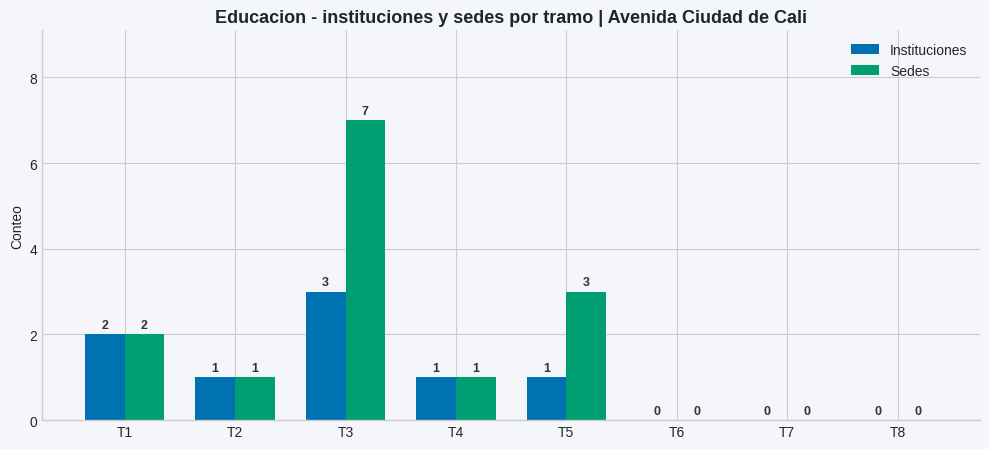

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(len(df_sedes_resumen))
w = 0.36

b1 = ax.bar(x - w/2, df_sedes_resumen['instituciones'], width=w, color=OKI_AZUL, label='Instituciones')
b2 = ax.bar(x + w/2, df_sedes_resumen['sedes'], width=w, color=OKI_VERDE, label='Sedes')

for bars in [b1, b2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.08, f'{int(h)}',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=OKI_GRIS)

ax.set_title('Educacion - instituciones y sedes por tramo | Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')
ax.set_xticks(x)
ax.set_xticklabels(df_sedes_resumen['tramo'])
ax.set_ylabel('Conteo')
ax.set_ylim(0, max(1, df_sedes_resumen['sedes'].max()) * 1.3)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'educacion_sedes_por_tramo.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 2. SIMPADE local - desertores por sede y tramo

Los archivos SIMPADE estan en `data/referencia/educacion/SIMPADE`. Para Avenida se filtra por `DANE_SEDE` de las sedes ubicadas en cada tramo.

In [10]:
SIMPADE_FILES = {
    2023: (REF_EDU_DIR / 'SIMPADE' / 'SIMPADE_2023-11.xlsx', 'xlsx'),
    2024: (REF_EDU_DIR / 'SIMPADE' / 'SIMPADE_2024-11.xlsx', 'xlsx'),
    2025: (REF_EDU_DIR / 'SIMPADE' / 'SIMPADE_2025-11.csv',  'csv'),
}

SIMPADE_USECOLS = {'DANE_SEDE', 'SECTOR', 'GRADO'}

def _usecols_simpade(col):
    c = str(col).strip().upper().replace(' ', '_')
    return c in SIMPADE_USECOLS

def read_table(path, fmt):
    print(f'  Leyendo {Path(path).name}...')
    if fmt == 'xlsx':
        return pd.read_excel(path, dtype=str, usecols=_usecols_simpade)
    return pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str, usecols=_usecols_simpade)

def preparar_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().upper().replace(' ', '_') for c in df.columns]
    return df

def clean_dane_code(s):
    return (
        s.astype(str)
         .str.strip()
         .str.replace(r'\.0$', '', regex=True)
         .str.replace(r'\s+', '', regex=True)
    )

def grado_valido_simat(s):
    g = pd.to_numeric(s, errors='coerce')
    return g.isin(GRADOS_EFIC)

def grado_valido_simpade(s):
    txt = normalize_text(s)
    excluir = (
        txt.str.contains('CICLO|ADULTO|JARDIN|KIND|PREJARDIN|PRE-JARDIN', na=False) |
        txt.isin(['-2', '-1', '12', '13', '21', '22', '23', '24', '25', '26', '41', '42', '43', '44', '45'])
    )
    # SIMPADE suele traer nombres de grado (SEXTO, DECIMO, ACELERACION),
    # no codigos numericos. Se excluyen adultos/prejardin y se conserva el resto.
    return ~excluir

def cargar_simpade_tramos(anio, path, fmt, df_sedes):
    if not Path(path).exists():
        print(f'SIMPADE {anio}: no existe {path}')
        return pd.DataFrame(columns=['anio','tramo','dane_sede','desertores'])

    df = preparar_cols(read_table(path, fmt))
    sedes = df_sedes[['tramo','dane_sede','institucion','sede']].drop_duplicates().copy()
    sedes['dane_sede'] = clean_dane_code(sedes['dane_sede'])

    if 'DANE_SEDE' not in df.columns:
        raise KeyError(f'SIMPADE {anio} no tiene columna DANE_SEDE.')

    df['DANE_SEDE'] = clean_dane_code(df['DANE_SEDE'])
    out = df.merge(sedes, left_on='DANE_SEDE', right_on='dane_sede', how='inner')

    if 'SECTOR' in out.columns:
        out = out[out['SECTOR'].astype(str).str.strip().str.upper() == 'OFICIAL'].copy()
    if 'GRADO' in out.columns:
        out = out[grado_valido_simpade(out['GRADO'])].copy()

    g = (out.groupby(['tramo','dane_sede','institucion','sede'], as_index=False)
            .size()
            .rename(columns={'size':'desertores'}))
    g['anio'] = anio
    return g[['anio','tramo','dane_sede','institucion','sede','desertores']]

rows = []
for anio, (path, fmt) in SIMPADE_FILES.items():
    tmp = cargar_simpade_tramos(anio, path, fmt, df_sedes)
    rows.append(tmp)
    print(f'SIMPADE {anio}: {int(tmp["desertores"].sum()) if not tmp.empty else 0} desertores en sedes del corredor')

df_simpade_sede = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# Panel completo sede-anio: si una sede no registra desertores en un anio,
# es cero observado, no dato faltante.
sedes_panel = df_sedes[['tramo','dane_sede','institucion','sede']].drop_duplicates().copy()
sedes_panel['dane_sede'] = clean_dane_code(sedes_panel['dane_sede'])
sedes_panel['_k'] = 1
anios_panel = pd.DataFrame({'anio': ANIOS_EDUC, '_k': 1})
panel_sede_anio = sedes_panel.merge(anios_panel, on='_k', how='outer').drop(columns='_k')

if df_simpade_sede.empty:
    df_simpade_sede = panel_sede_anio.copy()
    df_simpade_sede['desertores'] = 0
else:
    df_simpade_sede['dane_sede'] = clean_dane_code(df_simpade_sede['dane_sede'])
    df_simpade_sede = panel_sede_anio.merge(
        df_simpade_sede[['anio','tramo','dane_sede','desertores']],
        on=['anio','tramo','dane_sede'],
        how='left'
    )
    df_simpade_sede['desertores'] = df_simpade_sede['desertores'].fillna(0).astype(int)

idx = pd.MultiIndex.from_product([TRAMOS, ANIOS_EDUC], names=['tramo','anio']).to_frame(index=False)
df_des_tramo = (
    df_simpade_sede.groupby(['tramo','anio'], as_index=False)['desertores'].sum()
    if not df_simpade_sede.empty else pd.DataFrame(columns=['tramo','anio','desertores'])
)
df_des_tramo = idx.merge(df_des_tramo, on=['tramo','anio'], how='left')
df_des_tramo['desertores'] = df_des_tramo['desertores'].fillna(0).astype(int)

df_des_corredor = df_des_tramo.groupby('anio', as_index=False)['desertores'].sum()

print('Vista df_simpade_sede (primeras filas):')
display(df_simpade_sede.sort_values(['anio','tramo','sede']).head(30))
display(df_des_tramo)
display(df_des_corredor)

  Leyendo SIMPADE_2023-11.xlsx...
SIMPADE 2023: 469 desertores en sedes del corredor
  Leyendo SIMPADE_2024-11.xlsx...
SIMPADE 2024: 467 desertores en sedes del corredor
  Leyendo SIMPADE_2025-11.csv...
SIMPADE 2025: 363 desertores en sedes del corredor
Vista df_simpade_sede (primeras filas):


,tramo,dane_sede,institucion,sede,anio,desertores
3,T1,176001012089,Institucion Educativa Tecnico Industrial Pedro...,Los Vencedores,2023,41
0,T1,176001800133,Institucion Educativa Llano Verde,San Luis,2023,17
6,T2,176001006461,Institucion Educativa Tecnico Industrial Pedro...,San Luis,2023,42
9,T3,176001003942,Institucion Educativa Alfonso Lopez Pumarejo,Central Provivienda,2023,5
27,T3,176001004221,Institucion Educativa Siete De Agosto,Eleazar Libreros,2023,29
12,T3,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,Institucion Educativa Alfonso Lopez Pumarejo,2023,18
15,T3,176001003888,Institucion Educativa Alfonso Lopez Pumarejo,Los Farallones,2023,38
24,T3,176001006445,Institucion Educativa Vicente Borrero Costa,Presbitero Eloy Valenzuela,2023,32
18,T3,176001007336,Institucion Educativa Alfonso Lopez Pumarejo,Purificacion Trujillo,2023,19
21,T3,176001006470,Institucion Educativa Alfonso Lopez Pumarejo,Rafael Pombo,2023,24


,tramo,anio,desertores
0,T1,2023,58
1,T1,2024,75
2,T1,2025,59
3,T2,2023,42
4,T2,2024,30
5,T2,2025,22
6,T3,2023,165
7,T3,2024,174
8,T3,2025,153
9,T4,2023,53


,anio,desertores
0,2023,469
1,2024,467
2,2025,363


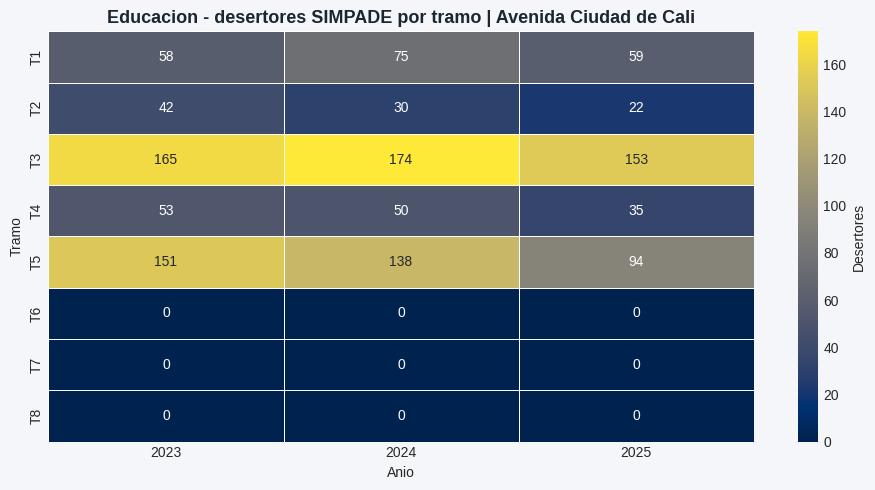

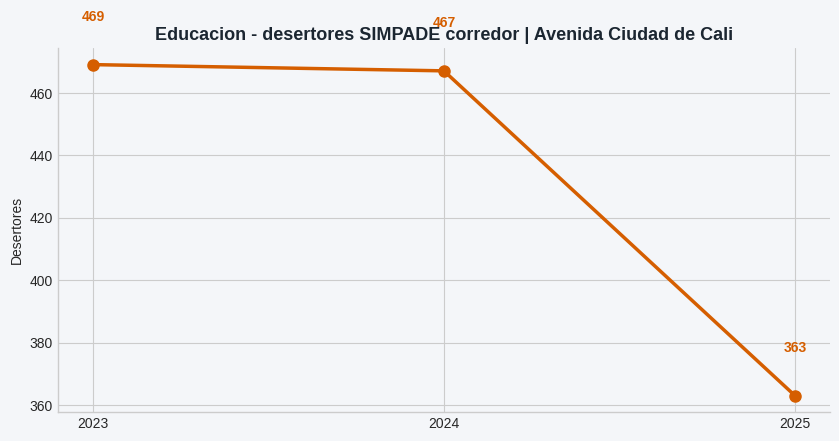

In [11]:
pivot_des = df_des_tramo.pivot(index='tramo', columns='anio', values='desertores').reindex(TRAMOS)
pivot_des = pivot_des.apply(pd.to_numeric, errors='coerce').fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 5), facecolor=BG)
sns.heatmap(pivot_des, annot=True, fmt='.0f', cmap='cividis',
            linewidths=0.5, linecolor='white', cbar_kws={'label':'Desertores'}, ax=ax)
ax.set_title('Educacion - desertores SIMPADE por tramo | Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')
ax.set_xlabel('Anio')
ax.set_ylabel('Tramo')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'educacion_simpade_desertores_heatmap_tramos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.5), facecolor=BG)
ax.set_facecolor(BG)
ax.plot(df_des_corredor['anio'], df_des_corredor['desertores'],
        color=OKI_BERMELL, linewidth=2.5, marker='o', markersize=8)
for _, r in df_des_corredor.iterrows():
    ax.text(r['anio'], r['desertores'] + max(1, df_des_corredor['desertores'].max()*0.03),
            f"{int(r['desertores'])}", ha='center', fontweight='bold', color=OKI_BERMELL)
ax.set_title('Educacion - desertores SIMPADE corredor | Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')
ax.set_xticks(ANIOS_EDUC)
ax.set_ylabel('Desertores')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'educacion_simpade_desertores_corredor.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 3. SIMAT Anexo 6A - matricula y repitentes

Para calcular tasas se requiere SIMAT Anexo 6A. Esta celda busca archivos locales y, en Colab, permite descargar una carpeta de Drive si se configura `SIMAT_DRIVE_FOLDER_ID`.

Si se usa Drive, pegar el ID de la carpeta que contiene `Anexo 6A` con diciembre 2023, diciembre 2024, diciembre 2025 y opcional marzo 2026.

In [12]:
# Carpeta Drive: SIMAT y SIMPADE anonimizados / Anexo 6A
SIMAT_DRIVE_FOLDER_ID = '1bzP9_uWaJ4dGfwWx18Di3flPQb3hOB6s'
SIMAT_LOCAL_DIR = Path('/content/simat_acc') if os.path.exists('/content') else (REF_EDU_DIR / 'SIMAT')

matricula_simat = {}
repitentes_simat = {}

def procesar_simat_6a_tramos(path_xlsx, anio, df_sedes):
    df = pd.read_excel(path_xlsx, dtype=str)
    df = preparar_cols(df)

    sedes = df_sedes[['tramo','dane_sede','institucion','sede']].drop_duplicates().copy()
    sedes['dane_sede'] = clean_dane_code(sedes['dane_sede'])

    # En Anexo 6A MEN, la sede suele venir como DANE_ANTERIOR.
    # En otros cortes/exportes puede aparecer como DANE_SEDE o CODIGO_DANE_SEDE.
    col_sede = next((c for c in ['DANE_ANTERIOR', 'DANE_SEDE', 'CODIGO_DANE_SEDE'] if c in df.columns), None)
    if col_sede is None:
        col_sede = next((c for c in df.columns if 'DANE' in c and 'SEDE' in c), None)
    if col_sede is None:
        raise KeyError(
            'No encontre columna de codigo DANE de sede en SIMAT 6A. '
            f'Columnas disponibles: {df.columns.tolist()[:40]}'
        )

    df[col_sede] = clean_dane_code(df[col_sede])
    out = df.merge(sedes, left_on=col_sede, right_on='dane_sede', how='inner')

    if 'SECTOR' in out.columns:
        out = out[out['SECTOR'].astype(str).str.strip().str.upper() == 'OFICIAL'].copy()
    col_grado = next((c for c in ['GRADO', 'COD_GRADO'] if c in out.columns), None)
    if col_grado is not None:
        out = out[grado_valido_simat(out[col_grado])].copy()

    rep_col = 'REPITENTE' if 'REPITENTE' in out.columns else None
    g = out.groupby(['tramo','dane_sede','institucion','sede'], as_index=False).size().rename(columns={'size':'matricula'})
    if rep_col:
        rep = (out.assign(_rep=out[rep_col].astype(str).str.strip().str.upper().eq('S').astype(int))
                 .groupby(['tramo','dane_sede'], as_index=False)['_rep'].sum()
                 .rename(columns={'_rep':'repitentes'}))
        g = g.merge(rep, on=['tramo','dane_sede'], how='left')
    else:
        g['repitentes'] = np.nan
    g['anio'] = anio
    return g[['anio','tramo','dane_sede','institucion','sede','matricula','repitentes']]

if os.path.exists('/content') and SIMAT_DRIVE_FOLDER_ID:
    if importlib.util.find_spec('gdown') is None:
        subprocess.run(['pip', 'install', 'gdown', '-q'], check=False)
    import gdown
    if not SIMAT_LOCAL_DIR.exists():
        print('Descargando carpeta SIMAT desde Drive...')
        gdown.download_folder(
            f'https://drive.google.com/drive/folders/{SIMAT_DRIVE_FOLDER_ID}',
            output=str(SIMAT_LOCAL_DIR), quiet=False, use_cookies=False
        )
    else:
        print(f'Carpeta SIMAT ya existe: {SIMAT_LOCAL_DIR}')

SIMAT_6A_DIR = SIMAT_LOCAL_DIR / 'Anexo 6A'
if not SIMAT_6A_DIR.exists():
    SIMAT_6A_DIR = SIMAT_LOCAL_DIR

print('Buscando SIMAT en:', SIMAT_6A_DIR)
all_simat_xlsx = sorted(SIMAT_6A_DIR.rglob('*.xlsx')) if SIMAT_6A_DIR.exists() else []
anexo6a_xlsx = [p for p in all_simat_xlsx if 'ANEXO 6' in normalize_text(pd.Series([p.name])).iloc[0] or '6A' in normalize_text(pd.Series([p.name])).iloc[0]]
if len(anexo6a_xlsx) == 0:
    anexo6a_xlsx = all_simat_xlsx

print('Archivos xlsx disponibles:', [p.name for p in anexo6a_xlsx])

rows_simat = []
for anio in ANIOS_EDUC:
    candidates = []
    if anexo6a_xlsx:
        candidates = [
            p for p in anexo6a_xlsx
            if str(anio) in p.name and (
                'DICIEMBRE' in normalize_text(pd.Series([p.name])).iloc[0] or
                p.name.strip().startswith('12')
            )
        ]
        if not candidates:
            candidates = [p for p in anexo6a_xlsx if str(anio) in p.name]
    if candidates:
        path = candidates[0]
        tmp = procesar_simat_6a_tramos(path, anio, df_sedes)
        rows_simat.append(tmp)
        print(f'SIMAT 6A {anio}: matricula={int(tmp["matricula"].sum())}, repitentes={int(tmp["repitentes"].fillna(0).sum())} [{path.name}]')
    else:
        print(f'SIMAT 6A {anio}: archivo no encontrado.')

df_simat_sede = pd.concat(rows_simat, ignore_index=True) if rows_simat else pd.DataFrame(
    columns=['anio','tramo','dane_sede','institucion','sede','matricula','repitentes']
)

df_simat_tramo = (
    df_simat_sede.groupby(['tramo','anio'], as_index=False)[['matricula','repitentes']].sum()
    if not df_simat_sede.empty else pd.DataFrame(columns=['tramo','anio','matricula','repitentes'])
)
df_simat_tramo = idx.merge(df_simat_tramo, on=['tramo','anio'], how='left')

df_simat_corredor = df_simat_tramo.groupby('anio', as_index=False)[['matricula','repitentes']].sum(min_count=1)

display(df_simat_sede.sort_values(['anio','tramo','sede']) if not df_simat_sede.empty else df_simat_sede)
display(df_simat_tramo)
display(df_simat_corredor)

Carpeta SIMAT ya existe: /content/simat_acc
Buscando SIMAT en: /content/simat_acc/Anexo 6A
Archivos xlsx disponibles: ['12.1 Anexo 6a Diciembre 2023.xlsx', '12.1 Anexo 6a Diciembre 2024.xlsx', '12.1 Anexo 6a Diciembre 2025.xlsx', '3.1 Anexo 6a Marzo 2023.xlsx', '3.1 Anexo 6a Marzo 2024.xlsx', '3.1 Anexo 6a Marzo 2025.xlsx', '3.1 Anexo 6a Marzo 2026.xlsx', '6.1 Anexo 6a Junio 2023.xlsx', '6.1 Anexo 6a Junio 2024.xlsx', '6.1 Anexo 6a Junio 2025.xlsx', '9.1 Anexo 6a Septiembre 2023.xlsx', '9.1 Anexo 6a Septiembre 2024.xlsx', '9.1 Anexo 6a Septiembre 2025.xlsx']
SIMAT 6A 2023: matricula=8131, repitentes=1009 [12.1 Anexo 6a Diciembre 2023.xlsx]
SIMAT 6A 2024: matricula=7703, repitentes=1600 [12.1 Anexo 6a Diciembre 2024.xlsx]
SIMAT 6A 2025: matricula=7652, repitentes=905 [12.1 Anexo 6a Diciembre 2025.xlsx]


,anio,tramo,dane_sede,institucion,sede,matricula,repitentes
0,2023,T1,176001012089,Institucion Educativa Tecnico Industrial Pedro...,Los Vencedores,1005,86
1,2023,T2,176001006461,Institucion Educativa Tecnico Industrial Pedro...,San Luis,699,68
3,2023,T3,176001003942,Institucion Educativa Alfonso Lopez Pumarejo,Central Provivienda,341,18
4,2023,T3,176001004221,Institucion Educativa Siete De Agosto,Eleazar Libreros,528,55
8,2023,T3,176001040101,Institucion Educativa Alfonso Lopez Pumarejo,Institucion Educativa Alfonso Lopez Pumarejo,353,19
2,2023,T3,176001003888,Institucion Educativa Alfonso Lopez Pumarejo,Los Farallones,739,124
5,2023,T3,176001006445,Institucion Educativa Vicente Borrero Costa,Presbitero Eloy Valenzuela,683,139
7,2023,T3,176001007336,Institucion Educativa Alfonso Lopez Pumarejo,Purificacion Trujillo,460,36
6,2023,T3,176001006470,Institucion Educativa Alfonso Lopez Pumarejo,Rafael Pombo,474,30
9,2023,T4,176001043791,Institucion Educativa Nuevo Latir,Institucion Educativa Nuevo Latir - Sede Princ...,1349,164


,tramo,anio,matricula,repitentes
0,T1,2023,1005.0,86.0
1,T1,2024,971.0,81.0
2,T1,2025,1016.0,84.0
3,T2,2023,699.0,68.0
4,T2,2024,472.0,33.0
5,T2,2025,510.0,27.0
6,T3,2023,3578.0,421.0
7,T3,2024,3508.0,995.0
8,T3,2025,3374.0,341.0
9,T4,2023,1349.0,164.0


,anio,matricula,repitentes
0,2023,8131.0,1009.0
1,2024,7703.0,1600.0
2,2025,7652.0,905.0


## 4. Tasas y score educativo

El score se calcula solo cuando hay denominador SIMAT. Si SIMAT no esta disponible, se conserva SIMPADE como conteo descriptivo y las tasas quedan `NaN`.

In [13]:
REF_DES_MIN, REF_DES_MAX = 0, 15
REF_REP_MIN, REF_REP_MAX = 0, 20

def score_ref(v, ref_min, ref_max, menor_mejora=True):
    if pd.isna(v):
        return np.nan
    if ref_max == ref_min:
        return 100.0
    z = (float(v) - ref_min) / (ref_max - ref_min)
    z = max(0, min(1, z))
    return round((1 - z) * 100, 1) if menor_mejora else round(z * 100, 1)

df_educ_tramo = df_des_tramo.merge(df_simat_tramo, on=['tramo','anio'], how='left')

mat_tramo = pd.to_numeric(df_educ_tramo['matricula'], errors='coerce').replace(0, np.nan)
des_tramo = pd.to_numeric(df_educ_tramo['desertores'], errors='coerce')
rep_tramo = pd.to_numeric(df_educ_tramo['repitentes'], errors='coerce')

df_educ_tramo['tasa_desercion'] = des_tramo.div(mat_tramo).mul(100)
df_educ_tramo['tasa_repitencia'] = rep_tramo.div(mat_tramo).mul(100)
df_educ_tramo['score_desercion'] = df_educ_tramo['tasa_desercion'].apply(lambda v: score_ref(v, REF_DES_MIN, REF_DES_MAX, True))
df_educ_tramo['score_repitencia'] = df_educ_tramo['tasa_repitencia'].apply(lambda v: score_ref(v, REF_REP_MIN, REF_REP_MAX, True))
df_educ_tramo['score_educacion'] = df_educ_tramo[['score_desercion','score_repitencia']].mean(axis=1)

df_educ_corredor = (
    df_educ_tramo.groupby('anio', as_index=False)
    .agg(desertores=('desertores','sum'),
         matricula=('matricula','sum'),
         repitentes=('repitentes','sum'))
)
mat_corr = pd.to_numeric(df_educ_corredor['matricula'], errors='coerce').replace(0, np.nan)
des_corr = pd.to_numeric(df_educ_corredor['desertores'], errors='coerce')
rep_corr = pd.to_numeric(df_educ_corredor['repitentes'], errors='coerce')

df_educ_corredor['tasa_desercion'] = des_corr.div(mat_corr).mul(100)
df_educ_corredor['tasa_repitencia'] = rep_corr.div(mat_corr).mul(100)
df_educ_corredor['score_desercion'] = df_educ_corredor['tasa_desercion'].apply(lambda v: score_ref(v, REF_DES_MIN, REF_DES_MAX, True))
df_educ_corredor['score_repitencia'] = df_educ_corredor['tasa_repitencia'].apply(lambda v: score_ref(v, REF_REP_MIN, REF_REP_MAX, True))
df_educ_corredor['score_educacion'] = df_educ_corredor[['score_desercion','score_repitencia']].mean(axis=1)

print('Educacion por tramo:')
display(df_educ_tramo.round(2))
print('Educacion corredor:')
display(df_educ_corredor.round(2))

Educacion por tramo:


,tramo,anio,desertores,matricula,repitentes,tasa_desercion,tasa_repitencia,score_desercion,score_repitencia,score_educacion
0,T1,2023,58,1005.0,86.0,5.77,8.56,61.5,57.2,59.35
1,T1,2024,75,971.0,81.0,7.72,8.34,48.5,58.3,53.40
2,T1,2025,59,1016.0,84.0,5.81,8.27,61.3,58.7,60.00
3,T2,2023,42,699.0,68.0,6.01,9.73,59.9,51.4,55.65
4,T2,2024,30,472.0,33.0,6.36,6.99,57.6,65.0,61.30
5,T2,2025,22,510.0,27.0,4.31,5.29,71.2,73.5,72.35
6,T3,2023,165,3578.0,421.0,4.61,11.77,69.3,41.2,55.25
7,T3,2024,174,3508.0,995.0,4.96,28.36,66.9,0.0,33.45
8,T3,2025,153,3374.0,341.0,4.53,10.11,69.8,49.5,59.65
9,T4,2023,53,1349.0,164.0,3.93,12.16,73.8,39.2,56.50


Educacion corredor:


,anio,desertores,matricula,repitentes,tasa_desercion,tasa_repitencia,score_desercion,score_repitencia,score_educacion
0,2023,469,8131.0,1009.0,5.77,12.41,61.5,38.0,49.75
1,2024,467,7703.0,1600.0,6.06,20.77,59.6,0.0,29.80
2,2025,363,7652.0,905.0,4.74,11.83,68.4,40.9,54.65


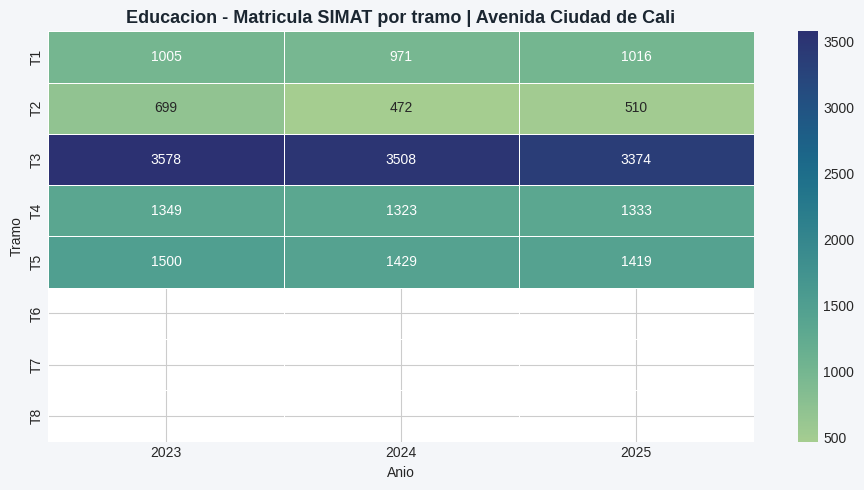

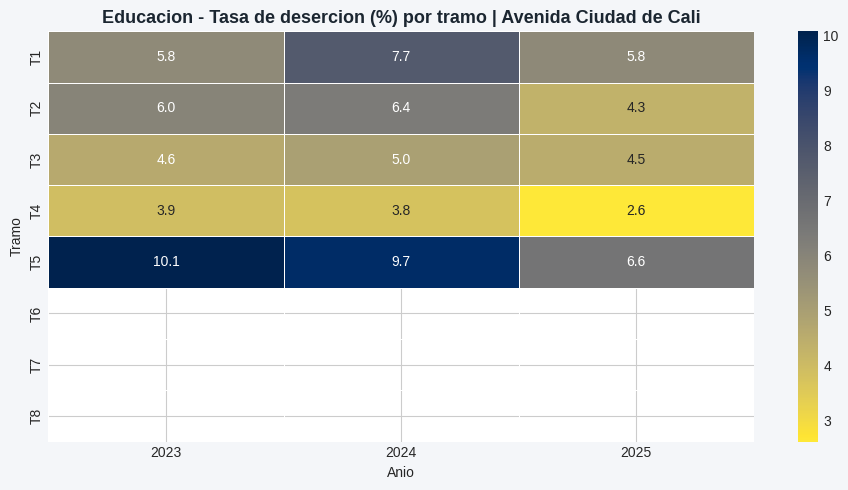

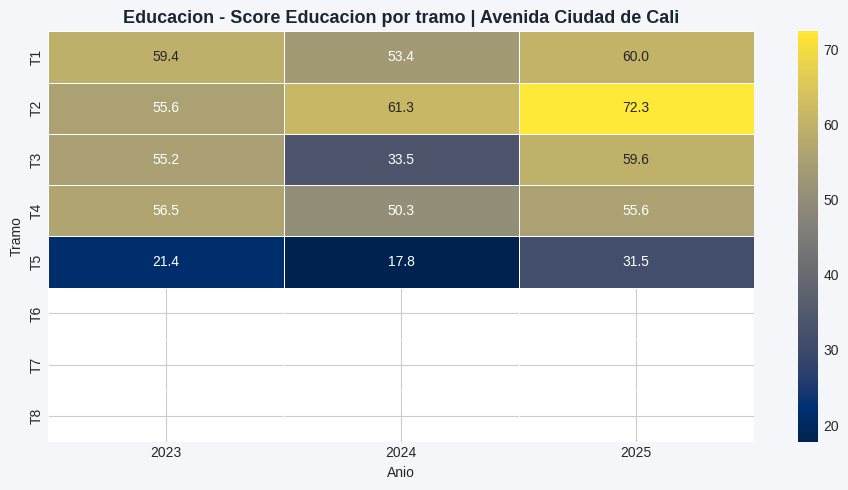

In [14]:
for col, titulo, cmap, fmt in [
    ('matricula', 'Matricula SIMAT por tramo', 'crest', '.0f'),
    ('tasa_desercion', 'Tasa de desercion (%) por tramo', 'cividis_r', '.1f'),
    ('score_educacion', 'Score Educacion por tramo', 'cividis', '.1f'),
]:
    pivot = df_educ_tramo.pivot(index='tramo', columns='anio', values=col).reindex(TRAMOS)
    pivot = pivot.apply(pd.to_numeric, errors='coerce')
    fig, ax = plt.subplots(figsize=(9.5, 5), facecolor=BG)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(f'Educacion - {titulo} | Avenida Ciudad de Cali',
                 fontsize=13, fontweight='bold', color='#1B2631')
    ax.set_xlabel('Anio')
    ax.set_ylabel('Tramo')
    plt.tight_layout()
    fname = f"educacion_{col}_heatmap_tramos.png"
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

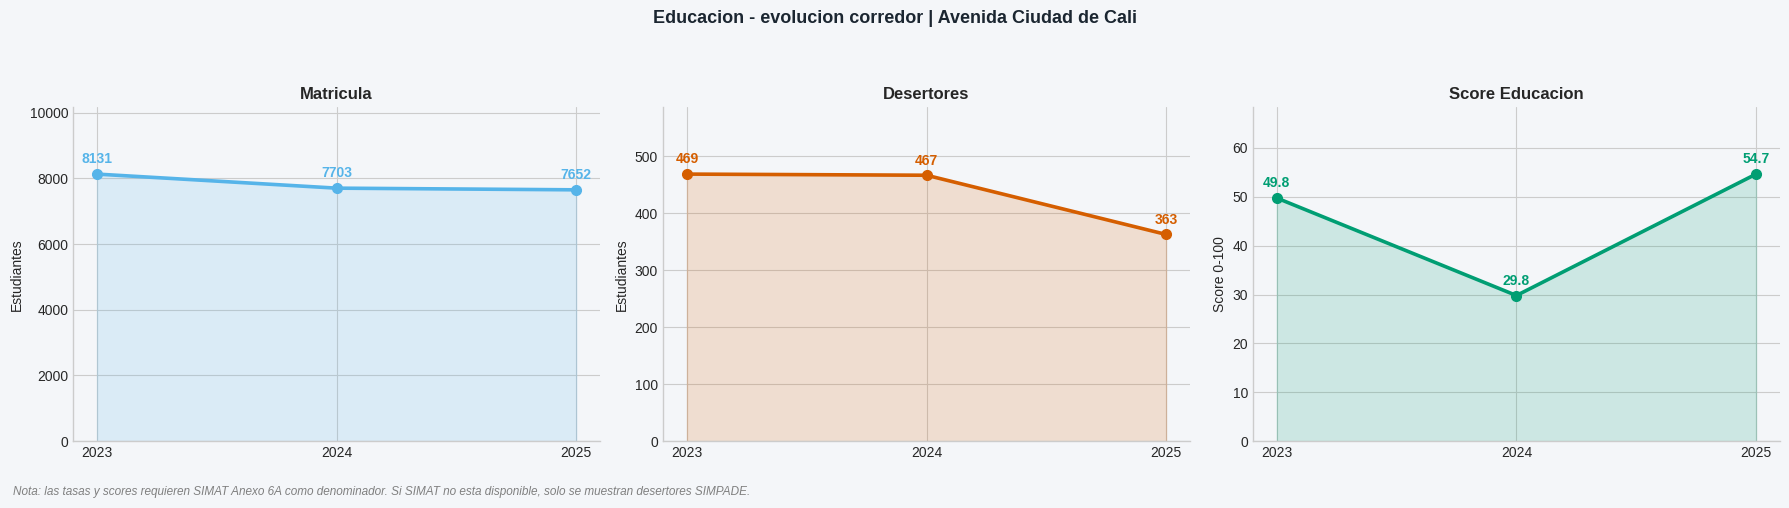

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Educacion - evolucion corredor | Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')

cfg = [
    ('matricula', 'Matricula', OKI_AZUL_C, 'Estudiantes'),
    ('desertores', 'Desertores', OKI_BERMELL, 'Estudiantes'),
    ('score_educacion', 'Score Educacion', OKI_VERDE, 'Score 0-100'),
]

for ax, (col, titulo, color, ylabel) in zip(axes, cfg):
    vals = df_educ_corredor[col].astype(float).to_numpy()
    x = np.arange(len(df_educ_corredor))
    ax.set_facecolor(BG)
    ax.plot(x, vals, color=color, linewidth=2.6, marker='o', markersize=7)
    ax.fill_between(x, vals, alpha=0.16, color=color)
    vmax = np.nanmax(vals) if not np.all(np.isnan(vals)) else 1
    for xi, v in zip(x, vals):
        if pd.notna(v):
            label = f'{v:.1f}' if col.startswith('score') else f'{int(v)}'
            ax.text(xi, v + vmax*0.04, label, ha='center', fontweight='bold', color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(df_educ_corredor['anio'].astype(str))
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, vmax*1.25 if vmax > 0 else 1)
    ax.spines[['top','right']].set_visible(False)

fig.text(
    0.01, 0.01,
    'Nota: las tasas y scores requieren SIMAT Anexo 6A como denominador. Si SIMAT no esta disponible, solo se muestran desertores SIMPADE.',
    fontsize=8.5, color='gray', style='italic'
)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig(OUTPUT_DIR / 'educacion_evolucion_corredor.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Corte parcial marzo 2026

Este bloque busca SIMAT marzo 2026 si existe. Se muestra solo como seguimiento; no reemplaza el cierre anual ni entra al score comparable 2023-2025.

Archivo 2026 detectado: 3.1 Anexo 6a Marzo 2026.xlsx


,tramo,matricula,repitentes,anio,corte
0,T1,1041,87,2026,Marzo
1,T2,494,26,2026,Marzo
2,T3,3549,327,2026,Marzo
3,T4,1400,184,2026,Marzo
4,T5,1456,259,2026,Marzo


,anio,corte,matricula,repitentes,tasa_repitencia
0,2026,Marzo,7940,883,11.120907


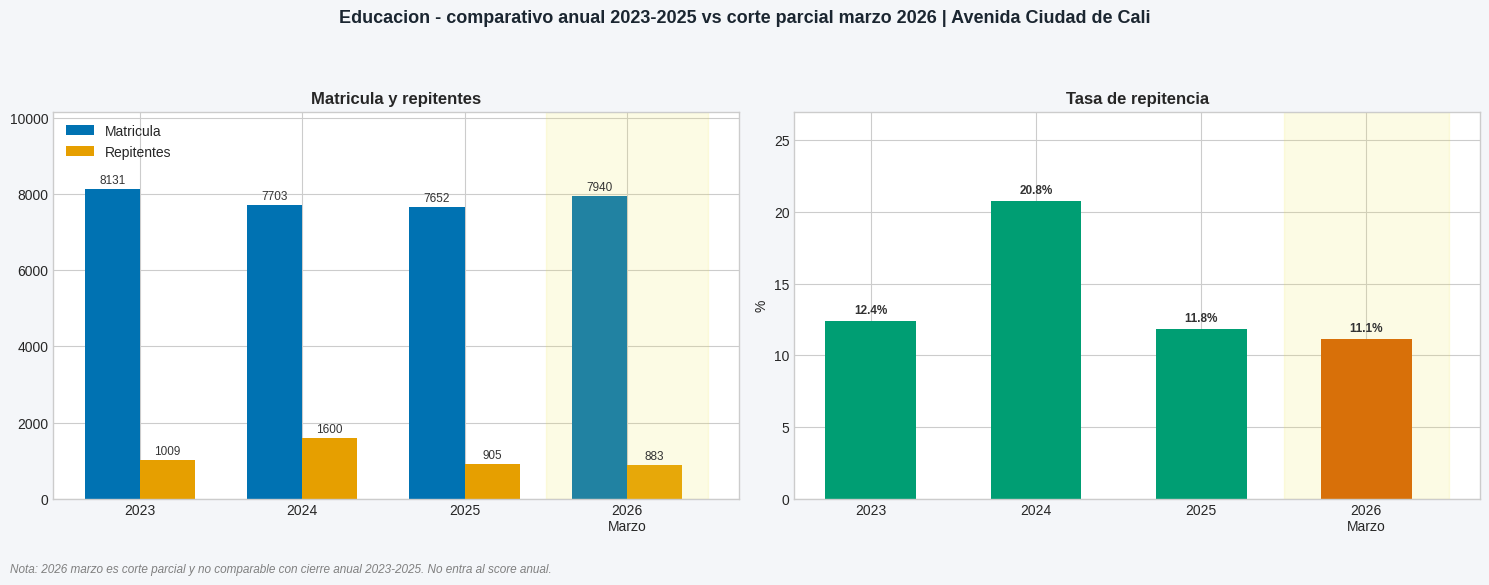

In [16]:
candidates_2026 = []
if 'anexo6a_xlsx' in globals() and anexo6a_xlsx:
    candidates_2026 = [
        p for p in anexo6a_xlsx
        if '2026' in p.name and (
            'MARZO' in normalize_text(pd.Series([p.name])).iloc[0] or
            p.name.strip().startswith('3')
        )
    ]
    if not candidates_2026:
        candidates_2026 = [p for p in anexo6a_xlsx if '2026' in p.name]
elif SIMAT_6A_DIR.exists():
    candidates_2026 = list(SIMAT_6A_DIR.rglob('*2026*.xlsx'))

if candidates_2026:
    simat_2026_path = candidates_2026[0]
    print(f'Archivo 2026 detectado: {simat_2026_path.name}')
    df_simat_2026_sede = procesar_simat_6a_tramos(simat_2026_path, 2026, df_sedes)
    df_simat_2026_tramo = df_simat_2026_sede.groupby(['tramo'], as_index=False)[['matricula','repitentes']].sum()
    df_simat_2026_tramo['anio'] = 2026
    df_simat_2026_tramo['corte'] = 'Marzo'
    df_simat_2026_corredor = pd.DataFrame([{
        'anio': 2026,
        'corte': 'Marzo',
        'matricula': df_simat_2026_tramo['matricula'].sum(),
        'repitentes': df_simat_2026_tramo['repitentes'].sum(),
    }])
    mat_2026 = pd.to_numeric(df_simat_2026_corredor['matricula'], errors='coerce').replace(0, np.nan)
    rep_2026 = pd.to_numeric(df_simat_2026_corredor['repitentes'], errors='coerce')
    df_simat_2026_corredor['tasa_repitencia'] = rep_2026.div(mat_2026).mul(100)
    display(df_simat_2026_tramo)
    display(df_simat_2026_corredor)

    df_hist = df_educ_corredor[df_educ_corredor['anio'].isin(ANIOS_EDUC)].copy()
    df_hist['label'] = df_hist['anio'].astype(str)
    df_mar = df_simat_2026_corredor.rename(columns={'matricula':'matricula', 'repitentes':'repitentes'})
    df_mar['label'] = '2026\nMarzo'
    df_plot = pd.concat([
        df_hist[['label','matricula','repitentes','tasa_repitencia']],
        df_mar[['label','matricula','repitentes','tasa_repitencia']]
    ], ignore_index=True)

    x = np.arange(len(df_plot))
    w = 0.34
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), facecolor=BG)
    fig.suptitle('Educacion - comparativo anual 2023-2025 vs corte parcial marzo 2026 | Avenida Ciudad de Cali',
                 fontsize=13, fontweight='bold', color='#1B2631')

    ax = axes[0]
    b1 = ax.bar(x - w/2, df_plot['matricula'], width=w, color=OKI_AZUL, label='Matricula')
    b2 = ax.bar(x + w/2, df_plot['repitentes'], width=w, color=OKI_NARANJA, label='Repitentes')
    ax.axvspan(len(df_plot)-1-0.5, len(df_plot)-1+0.5, color=OKI_AMARILLO, alpha=0.14)
    ymax = float(df_plot['matricula'].fillna(0).max()) * 1.25
    ax.set_ylim(0, ymax if ymax > 0 else 1)
    for b in list(b1) + list(b2):
        h = b.get_height()
        if pd.notna(h):
            ax.text(b.get_x()+b.get_width()/2, h + max(1, ymax*0.015), f'{int(h)}',
                    ha='center', fontsize=8.5, color=OKI_GRIS)
    ax.set_xticks(x); ax.set_xticklabels(df_plot['label'])
    ax.set_title('Matricula y repitentes', fontweight='bold')
    ax.legend(frameon=False)

    ax2 = axes[1]
    colors = [OKI_VERDE] * (len(df_plot)-1) + [OKI_BERMELL]
    bars = ax2.bar(x, df_plot['tasa_repitencia'], color=colors, width=0.55)
    ax2.axvspan(len(df_plot)-1-0.5, len(df_plot)-1+0.5, color=OKI_AMARILLO, alpha=0.14)
    ymax2 = float(df_plot['tasa_repitencia'].fillna(0).max()) * 1.3
    ax2.set_ylim(0, ymax2 if ymax2 > 0 else 1)
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            ax2.text(b.get_x()+b.get_width()/2, h + max(0.1, ymax2*0.02), f'{h:.1f}%',
                     ha='center', fontsize=8.5, fontweight='bold', color=OKI_GRIS)
    ax2.set_xticks(x); ax2.set_xticklabels(df_plot['label'])
    ax2.set_title('Tasa de repitencia', fontweight='bold')
    ax2.set_ylabel('%')

    fig.text(0.01, 0.01,
             'Nota: 2026 marzo es corte parcial y no comparable con cierre anual 2023-2025. No entra al score anual.',
             fontsize=8.5, color='gray', style='italic')
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.savefig(OUTPUT_DIR / 'educacion_comparativo_2023_2025_marzo_2026.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
else:
    print('No se encontro SIMAT marzo 2026. Este bloque queda pendiente hasta tener el archivo.')

## 6. Exportacion

In [17]:
EXPORT_PATH = OUTPUT_DIR / 'Educacion_Avenida_Ciudad_de_Cali.xlsx'

sheets = {
    'Sedes_Tramos': df_sedes,
    'Resumen_Sedes_Tramos': df_sedes_resumen,
    'SIMPADE_Sede': df_simpade_sede,
    'Desertores_Tramo': df_des_tramo,
    'Desertores_Corredor': df_des_corredor,
    'SIMAT_Sede': df_simat_sede,
    'Educacion_Tramo': df_educ_tramo,
    'Educacion_Corredor': df_educ_corredor,
}

with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    for name, df_sh in sheets.items():
        if isinstance(df_sh, pd.DataFrame) and not df_sh.empty:
            df_sh.round(2).to_excel(writer, sheet_name=name[:31], index=False)
        else:
            pd.DataFrame({'nota': ['Sin datos o ejecutar celdas previas']}).to_excel(writer, sheet_name=name[:31], index=False)

print(f'Exportado: {EXPORT_PATH}')

if os.path.exists('/content'):
    import base64
    from IPython.display import HTML, display
    with open(EXPORT_PATH, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    mime = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
    display(HTML(
        f'<a href="data:{mime};base64,{b64}" download="Educacion_Avenida_Ciudad_de_Cali.xlsx">'
        '<b>Haz click aqui para descargar el Excel de Educacion</b></a>'
    ))

Exportado: /content/itt_repos_cali/outputs/educacion_avenida_ciudad_de_cali/Educacion_Avenida_Ciudad_de_Cali.xlsx
